In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('youtube_channel_real_performance_analytics.csv')

In [3]:
df.shape

(364, 70)

In [4]:
df.head()

,ID,Video Duration,Video Publish Time,Days Since Publish,Day,Month,Year,Day of Week,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration,Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
0,0,201.0,2016-06-02 00:00:00,0,2,6,2016,Thursday,0.024,723.0,...,0.0,0.0,40.38,81.0,23531.0,533.1636,51.0,0.561,41118.0,27.66
1,1,391.0,2016-06-10 00:00:00,8,10,6,2016,Friday,0.056,727.0,...,0.0,0.0,39.85,156.0,11478.0,500.5628,33.0,0.648,41627.0,5.85
2,2,133.0,2016-06-14 00:00:00,4,14,6,2016,Tuesday,0.014,76.0,...,0.0,0.0,30.88,41.0,6153.0,70.7287,8.0,0.089,38713.0,7.07
3,3,14.0,2016-06-29 00:00:00,15,29,6,2016,Wednesday,0.004,18.0,...,0.0,0.0,103.05,14.0,4398.0,17.6251,2.0,0.017,35245.0,5.60
4,4,45.0,2016-07-01 00:00:00,2,1,7,2016,Friday,0.000,0.0,...,0.0,0.0,55.70,25.0,14659.0,104.3341,28.0,0.000,46218.0,8.62


In [5]:
print("\nColumn names (first 15):")
print(df.columns[:15].tolist())


Column names (first 15):
['ID', 'Video Duration', 'Video Publish Time', 'Days Since Publish', 'Day', 'Month', 'Year', 'Day of Week', 'Revenue per 1000 Views (USD)', 'Monetized Playbacks (Estimate)', 'Playback-Based CPM (USD)', 'CPM (USD)', 'Ad Impressions', 'Estimated AdSense Revenue (USD)', 'DoubleClick Revenue (USD)']


In [6]:
# Dataset overview
print("Dataset Info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum().sum(), "total missing values")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 70 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ID                                  364 non-null    int64  
 1   Video Duration                      364 non-null    float64
 2   Video Publish Time                  364 non-null    object 
 3   Days Since Publish                  364 non-null    int64  
 4   Day                                 364 non-null    int64  
 5   Month                               364 non-null    int64  
 6   Year                                364 non-null    int64  
 7   Day of Week                         364 non-null    object 
 8   Revenue per 1000 Views (USD)        364 non-null    float64
 9   Monetized Playbacks (Estimate)      364 non-null    float64
 10  Playback-Based CPM (USD)            364 non-null    float64
 11  CPM (USD)                      

In [7]:
# Basic statistics for key metrics
key_metrics = ['Views', 'Estimated Revenue (USD)', 'Subscribers', 'Watch Time (hours)']
print("\nKey metrics statistics:")
print(df[key_metrics].describe())


Key metrics statistics:
               Views  Estimated Revenue (USD)  Subscribers  Watch Time (hours)
count     364.000000               364.000000   364.000000          364.000000
mean   128800.101648                 8.852052   321.024725        10058.965455
std    118209.844270                13.414650   444.594763         9516.160361
min      2461.000000                 0.000000    -3.000000           12.697900
25%     27160.500000                 0.443250    41.000000         2759.404250
50%    101950.500000                 4.285000   180.000000         8102.962950
75%    198169.500000                11.476250   421.250000        14084.498550
max    670990.000000               103.117000  3728.000000        53794.658700


In [8]:
# Step 3: Import datetime processing
import pandas as pd
from datetime import datetime

# Convert publish time to datetime
df['Video Publish Time'] = pd.to_datetime(df['Video Publish Time'])

# Extract date components
print("Date range:", df['Video Publish Time'].min(), "to", df['Video Publish Time'].max())

# Days since publish should already be calculated
print("\nDays Since Publish - Min/Max:", df['Days Since Publish'].min(), df['Days Since Publish'].max())

Date range: 2016-06-02 00:00:00 to 2024-10-18 00:00:00

Days Since Publish - Min/Max: 0 260


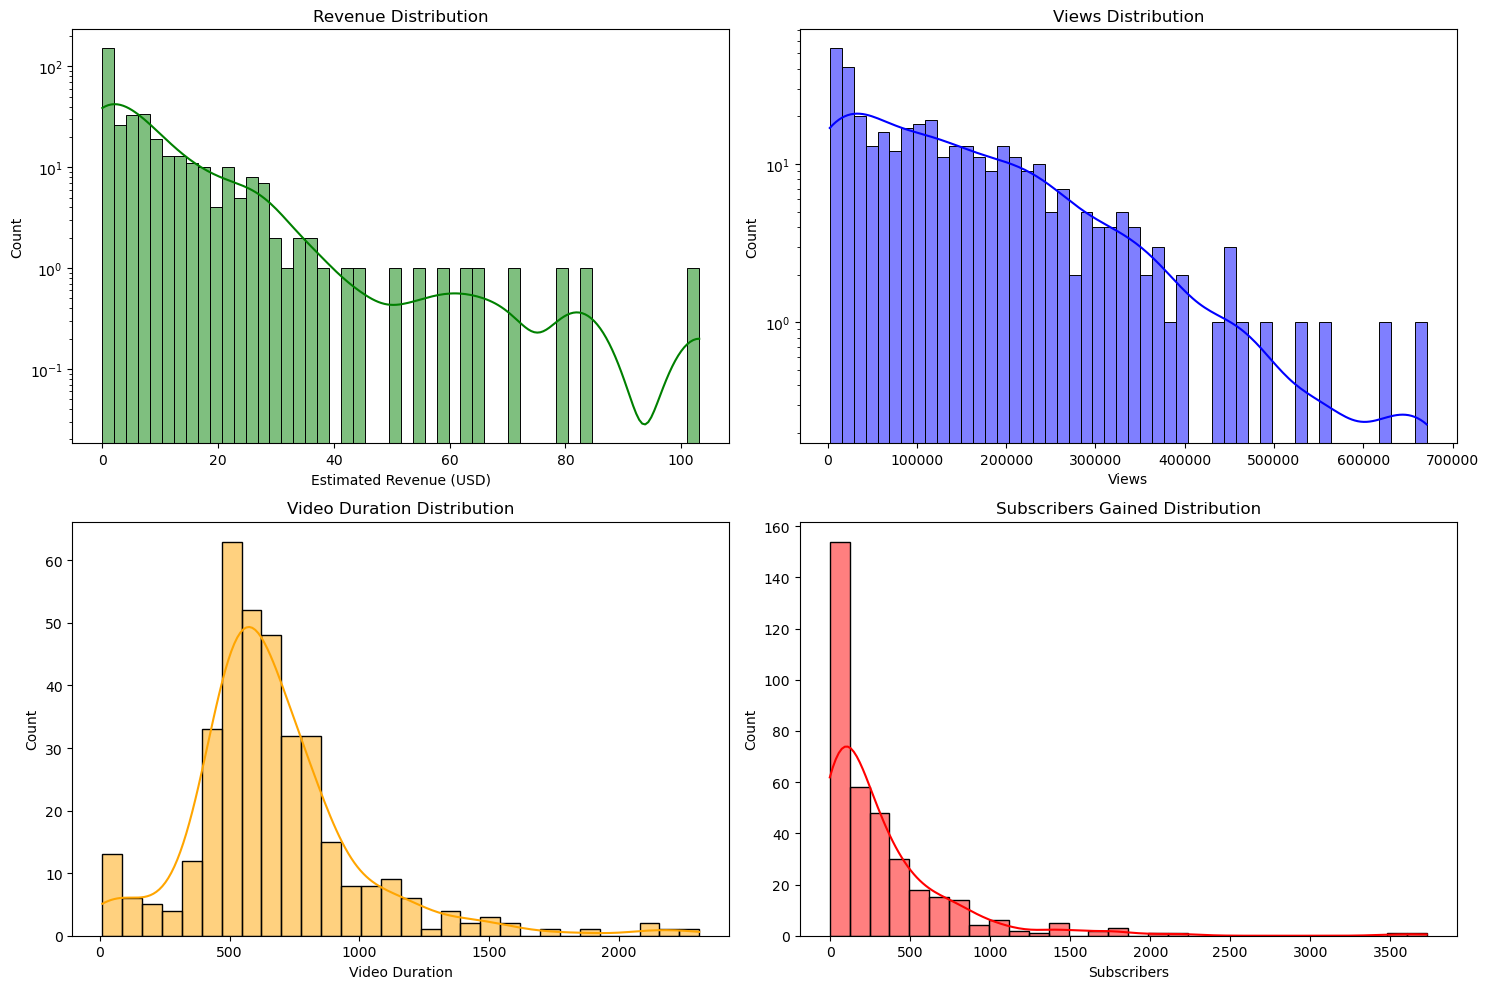

In [9]:
# Step 4:plots for distributions
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_palette("husl")

# Set figure size
plt.figure(figsize=(15, 10))

# 2x2 subplot for key distributions
plt.subplot(2, 2, 1)
sns.histplot(df['Estimated Revenue (USD)'], bins=50, kde=True, color='green')
plt.title('Revenue Distribution')
plt.yscale('log')

plt.subplot(2, 2, 2)
sns.histplot(df['Views'], bins=50, kde=True, color='blue')
plt.title('Views Distribution')
plt.yscale('log')

plt.subplot(2, 2, 3)
sns.histplot(df['Video Duration'], bins=30, kde=True, color='orange')
plt.title('Video Duration Distribution')

plt.subplot(2, 2, 4)
sns.histplot(df['Subscribers'], bins=30, kde=True, color='red')
plt.title('Subscribers Gained Distribution')

plt.tight_layout()
plt.show()


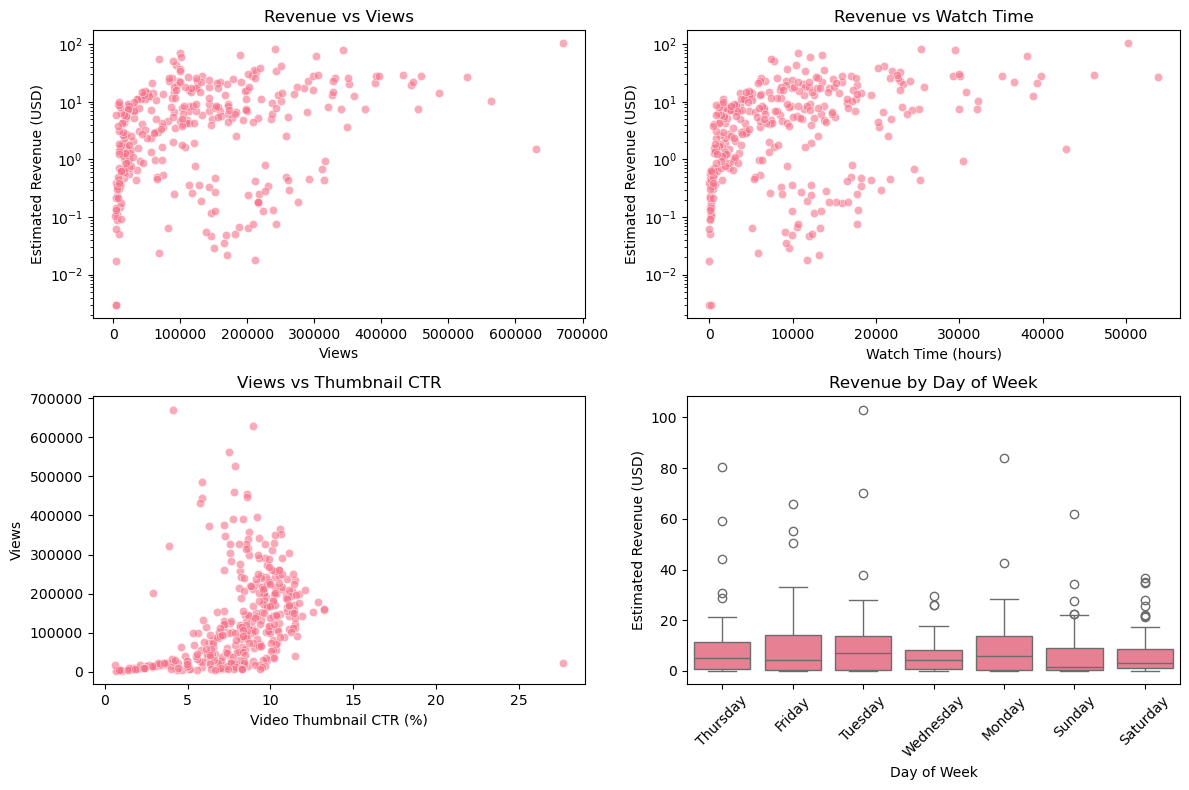

In [10]:
# Revenue vs Views scatterplot
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x='Views', y='Estimated Revenue (USD)', alpha=0.6)
plt.title('Revenue vs Views')
plt.yscale('log')

plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='Watch Time (hours)', y='Estimated Revenue (USD)', alpha=0.6)
plt.title('Revenue vs Watch Time')
plt.yscale('log')

plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='Video Thumbnail CTR (%)', y='Views', alpha=0.6)
plt.title('Views vs Thumbnail CTR')

plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='Day of Week', y='Estimated Revenue (USD)')
plt.title('Revenue by Day of Week')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

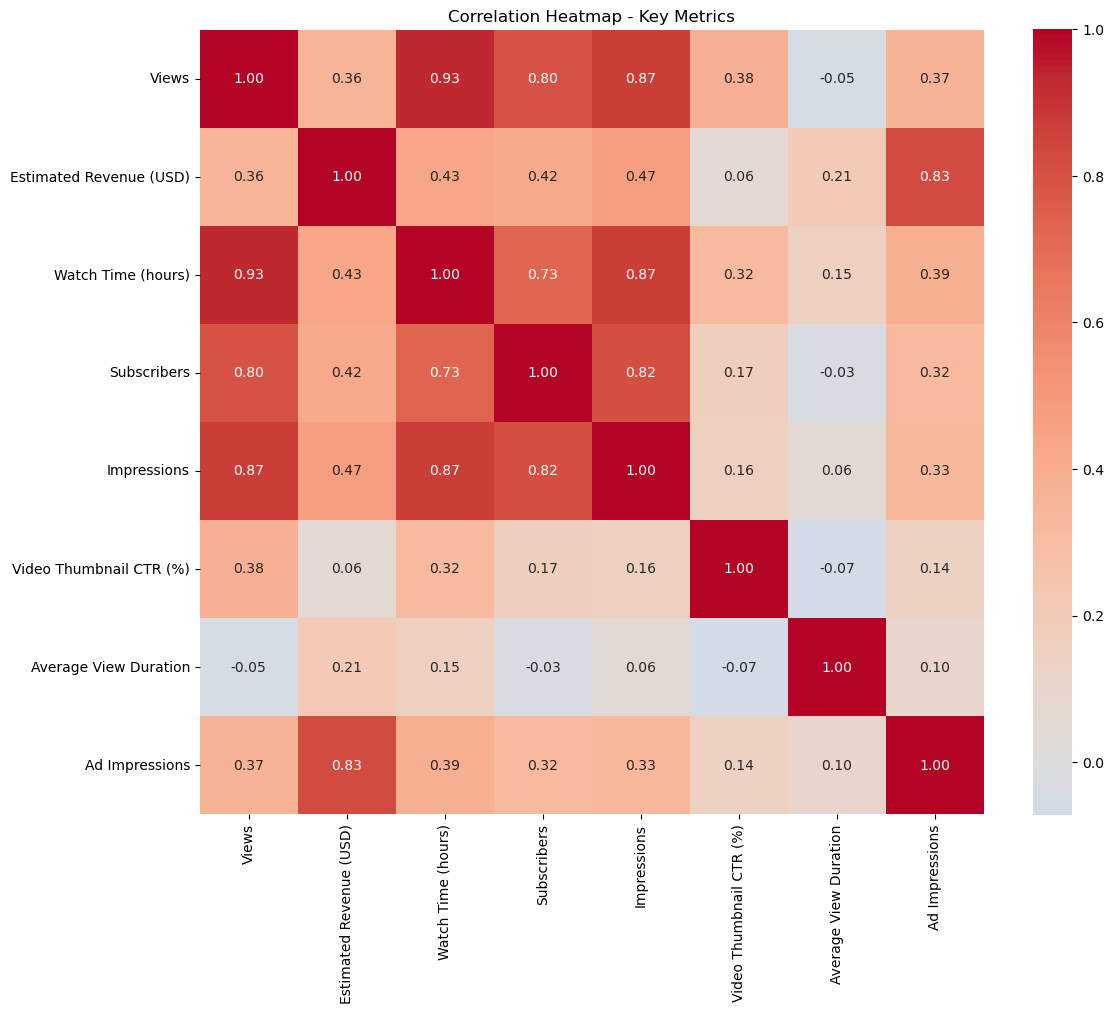

Top correlations with Revenue:
Estimated Revenue (USD)    1.000000
Ad Impressions             0.825534
Impressions                0.469940
Watch Time (hours)         0.431998
Subscribers                0.418177
Views                      0.357901
Average View Duration      0.207286
Video Thumbnail CTR (%)    0.059658
Name: Estimated Revenue (USD), dtype: float64


In [11]:
# Step 6: Correlation analysis
# Select numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Plot heatmap for key metrics only (too many columns = cluttered)
key_corr_cols = ['Views', 'Estimated Revenue (USD)', 'Watch Time (hours)', 
                'Subscribers', 'Impressions', 'Video Thumbnail CTR (%)',
                'Average View Duration', 'Ad Impressions']

plt.figure(figsize=(12, 10))
sns.heatmap(df[key_corr_cols].corr(), annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Correlation Heatmap - Key Metrics')
plt.tight_layout()
plt.show()

print("Top correlations with Revenue:")
revenue_corr = df[key_corr_cols].corr()['Estimated Revenue (USD)'].sort_values(ascending=False)
print(revenue_corr)

In [12]:
# Step 7: Create new features
# Engagement rate
df['Engagement Rate (%)'] = (df['Likes'] + df['Shares'] + df['New Comments']) / df['Views'] * 100

# Revenue per view
df['Revenue per View'] = df['Estimated Revenue (USD)'] / df['Views']

# Retention rate
df['Retention Rate (%)'] = df['Average View Percentage (%)']

# Views per subscriber gained
df['Views per Subscriber'] = df['Views'] / (df['New Subscribers'] + 1)

print("New features created:")
print(df[['Engagement Rate (%)', 'Revenue per View', 'Retention Rate (%)']].describe())

New features created:
       Engagement Rate (%)  Revenue per View  Retention Rate (%)
count           364.000000        364.000000          364.000000
mean              5.443156          0.000112           45.970989
std               2.138080          0.000178           12.457470
min               2.351136          0.000000           15.050000
25%               3.906932          0.000015           40.252500
50%               4.951214          0.000050           45.465000
75%               6.627732          0.000144           51.010000
max              13.422661          0.001521          117.300000


In [13]:
# Step 8: Analyze top performers
print("=== TOP 10 VIDEOS BY REVENUE ===")
top_revenue = df.nlargest(10, 'Estimated Revenue (USD)')[[
    'ID', 'Video Publish Time', 'Views', 'Estimated Revenue (USD)', 
    'Subscribers', 'Engagement Rate (%)', 'Video Thumbnail CTR (%)'
]].round(2)
print(top_revenue)

print("\n=== TOP 10 BY VIEWS ===")
top_views = df.nlargest(10, 'Views')[[
    'ID', 'Video Publish Time', 'Views', 'Estimated Revenue (USD)', 
    'Engagement Rate (%)'
]].round(2)
print(top_views)

print("\n=== BEST DAY OF WEEK FOR REVENUE ===")
day_revenue = df.groupby('Day of Week')['Estimated Revenue (USD)'].agg(['mean', 'count', 'sum']).round(2)
print(day_revenue.sort_values('mean', ascending=False))

=== TOP 10 VIDEOS BY REVENUE ===
      ID Video Publish Time     Views  Estimated Revenue (USD)  Subscribers  \
228  228         2018-10-30  670990.0                   103.12       3538.0   
257  257         2020-03-23  241060.0                    83.98       1125.0   
251  251         2019-10-24  343319.0                    80.26       1437.0   
289  289         2021-10-26   99196.0                    70.25        350.0   
278  278         2021-04-16  188324.0                    65.98       1824.0   
260  260         2020-06-21  302999.0                    62.05        866.0   
293  293         2021-11-25  101025.0                    59.06        602.0   
294  294         2021-12-17   67556.0                    55.04        581.0   
290  290         2021-11-05   89284.0                    50.34        995.0   
284  284         2021-08-05   93487.0                    44.23        305.0   

     Engagement Rate (%)  Video Thumbnail CTR (%)  
228                 4.86                     

In [14]:
# Step 9: Building Models
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Prepare features and target
features = ['Views', 'Watch Time (hours)', 'Subscribers', 'Impressions', 
           'Video Thumbnail CTR (%)', 'Average View Duration', 
           'Engagement Rate (%)', 'Video Duration']

X = df[features].fillna(0)
y = df['Estimated Revenue (USD)']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:")
print(f"RMSE: ${rmse:.2f}")
print(f"R² Score: {r2:.3f}")

Model Performance:
RMSE: $9.59
R² Score: -0.056


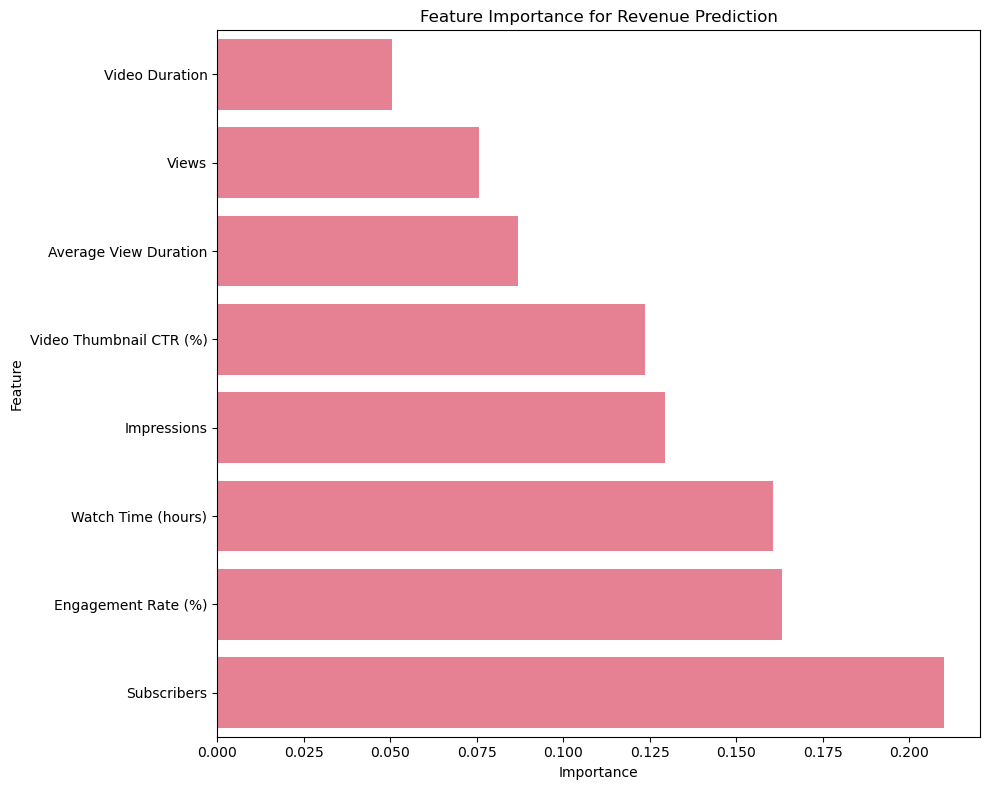


Feature Importance Ranking:
                   Feature  Importance
7           Video Duration    0.050640
0                    Views    0.075672
5    Average View Duration    0.086970
4  Video Thumbnail CTR (%)    0.123573
3              Impressions    0.129365
1       Watch Time (hours)    0.160556
6      Engagement Rate (%)    0.163326
2              Subscribers    0.209899


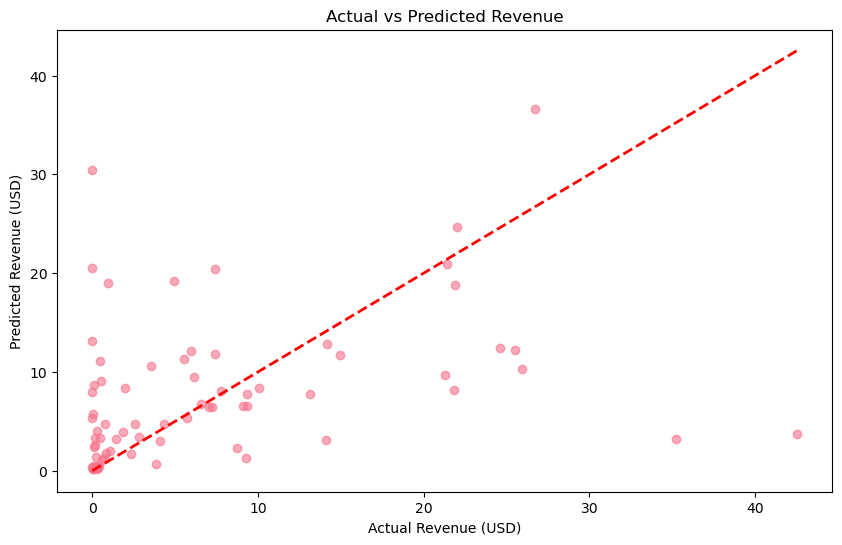

In [15]:
# Step 10: Model interpretation and final plots
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# Feature importance plot
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Feature Importance for Revenue Prediction')
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
print(importance_df)

# Bonus: Revenue prediction vs actual for test set
plt.figure(figsize=(10, 6))
test_indices = X_test.index
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Revenue (USD)')
plt.ylabel('Predicted Revenue (USD)')
plt.title('Actual vs Predicted Revenue')
plt.show()

In [16]:
import joblib
joblib.dump(rf_model, 'youtube_revenue_predictor.pkl')
print("✅ Model saved - Project complete!")

✅ Model saved - Project complete!
